In [240]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading database

In [241]:

train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (1460, 81)
Test shape: (1459, 80)


### Basic info and initial inspection

In [242]:

print(train.info())
print(test.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Display basic statistics of numerical features


In [243]:
print(train.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

### Checking for missing values

In [244]:

def missing_values(df):
    null_count=df.isnull().sum()
    null_percent=(null_count / len(df)) * 100
    return pd.DataFrame({'MissingCount': null_count, 'MissingPercent': null_percent}).sort_values(by='MissingPercent', ascending=False)

train_missing=missing_values(train)
test_missing=missing_values(test)

print(train_missing[train_missing.MissingCount > 0])
print(test_missing[test_missing.MissingCount > 0])


              MissingCount  MissingPercent
PoolQC                1453       99.520548
MiscFeature           1406       96.301370
Alley                 1369       93.767123
Fence                 1179       80.753425
MasVnrType             872       59.726027
FireplaceQu            690       47.260274
LotFrontage            259       17.739726
GarageYrBlt             81        5.547945
GarageCond              81        5.547945
GarageType              81        5.547945
GarageFinish            81        5.547945
GarageQual              81        5.547945
BsmtFinType2            38        2.602740
BsmtExposure            38        2.602740
BsmtQual                37        2.534247
BsmtCond                37        2.534247
BsmtFinType1            37        2.534247
MasVnrArea               8        0.547945
Electrical               1        0.068493
              MissingCount  MissingPercent
PoolQC                1456       99.794380
MiscFeature           1408       96.504455
Alley      

### Drop features with too many missing values

In [245]:

drop_cols=['Alley', 'PoolQC', 'Fence', 'MiscFeature','MasVnrType', 'FireplaceQu']  # these have high missing values
train=train.drop(columns=drop_cols)
test=test.drop(columns=drop_cols)


### Filling missing values for remaining features


#### Categorical columns: Fill with mode

In [246]:

cat_cols=train.select_dtypes(include='object').columns

for col in cat_cols:
    if (train[col].isnull().sum() > 0) or (col in test.columns and test[col].isnull().sum() > 0):
        mode_val=train[col].mode()[0]
        if train[col].isnull().sum() > 0:
            train[col]=train[col].fillna(mode_val)
        if col in test.columns and test[col].isnull().sum() > 0:
            test[col]=test[col].fillna(mode_val)



#### Numerical columns: Fill with median


In [247]:
num_cols=train.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if train[col].isnull().sum() > 0:
        median_val=train[col].median()
        train[col]=train[col].fillna(median_val)
    if col in test.columns and test[col].isnull().sum() > 0:
        test[col]=test[col].fillna(median_val)


### Feature Engineering

In [248]:
# Total square footage
train['TotalSF']=train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF']=test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

# House age
train['HouseAge']=2025 - train['YearBuilt']
test['HouseAge']=2025 - test['YearBuilt']

# Log transformation of the target variable
train['SalePrice']=np.log1p(train['SalePrice'])

### Encode categorical variables using one-hot encoding


In [249]:
train_encoded=pd.get_dummies(train, drop_first=True)
test_encoded=pd.get_dummies(test, drop_first=True)

# Aligning columns between train and test
train_encoded, test_encoded=train_encoded.align(test_encoded, join='left', axis=1)
test_encoded=test_encoded.fillna(0)
if 'SalePrice' in test_encoded.columns:
    test_encoded=test_encoded.drop('SalePrice', axis=1)


### Separating features and target


In [250]:
X=train_encoded.drop('SalePrice', axis=1)
y=train_encoded['SalePrice']


### Train/Validation Split (Internal Validation)

In [251]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

X_train, X_valid, y_train, y_valid=train_test_split(X, y, test_size=0.2, random_state=42)


## Linear Regression

In [252]:
lr_model=LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds=lr_model.predict(X_valid)
lr_rmse=np.sqrt(mean_squared_error(y_valid, lr_preds))
print("Linear Regression RMSE (log SalePrice):", lr_rmse)


Linear Regression RMSE (log SalePrice): 0.2080125234965815


## Ridge Regression

In [253]:
ridge_model=Ridge(alpha=10)
ridge_model.fit(X_train, y_train)

ridge_preds=ridge_model.predict(X_valid)
ridge_rmse=np.sqrt(mean_squared_error(y_valid, ridge_preds))
print("Ridge Regression RMSE (log SalePrice):", ridge_rmse)


Ridge Regression RMSE (log SalePrice): 0.13685513490976178


### Training Ridge on full data

In [254]:


test_features=test_encoded

final_model=Ridge(alpha=10)
final_model.fit(X, y)

# Predicting on the test set
test_preds_log=final_model.predict(test_features)

# Convert back to original price scale
test_preds=np.expm1(test_preds_log)


In [255]:
# Create submission file
submission=pd.read_csv('sample_submission.csv')
submission['SalePrice']=test_preds
submission.to_csv('ridge_submission.csv', index=False)
print("Submission file saved as ridge_submission.csv")


Submission file saved as ridge_submission.csv


### Random Forest

In [256]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds=rf_model.predict(X_valid)
rf_rmse=np.sqrt(mean_squared_error(y_valid, rf_preds))
print("Random Forest RMSE (log SalePrice):", rf_rmse)


Random Forest RMSE (log SalePrice): 0.1489327785140306


# Training Random Forest on full training data
rf_model_full=RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_full.fit(X, y)

test_preds_log=rf_model_full.predict(test_encoded)
test_preds=np.expm1(test_preds_log)

# Create submission file
submission_rf=pd.read_csv('sample_submission.csv')
submission_rf['SalePrice']=test_preds
submission_rf.to_csv('rf_submission.csv', index=False)
print("Random Forest submission saved as rf_submission.csv")


In [257]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds=rf_model.predict(X_valid)
rf_rmse=np.sqrt(mean_squared_error(y_valid, rf_preds))
print("Random Forest RMSE (log SalePrice):", rf_rmse)


Random Forest RMSE (log SalePrice): 0.1489327785140306


In [258]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model=GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)

gb_preds=gb_model.predict(X_valid)
gb_rmse=np.sqrt(mean_squared_error(y_valid, gb_preds))
print("Gradient Boosting RMSE (log SalePrice):", gb_rmse)


Gradient Boosting RMSE (log SalePrice): 0.14315573761310502


### Different rmse values for different models

In [259]:
print("Model RMSE (log SalePrice):")
print(f"Linear Regression:      {lr_rmse:.5f}")
print(f"Ridge Regression:       {ridge_rmse:.5f}")
print(f"Random Forest:          {rf_rmse:.5f}")
print(f"Gradient Boosting:      {gb_rmse:.5f}")


Model RMSE (log SalePrice):
Linear Regression:      0.20801
Ridge Regression:       0.13686
Random Forest:          0.14893
Gradient Boosting:      0.14316


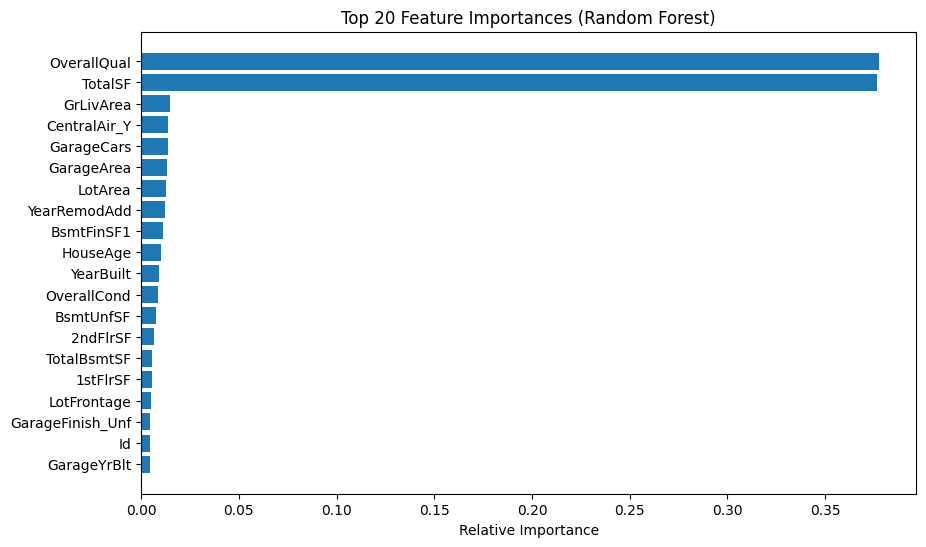

In [260]:
import matplotlib.pyplot as plt

import numpy as np

importances=rf_model.feature_importances_
indices=np.argsort(importances)[-20:]  # Top 20 features
features=X.columns[indices]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), features)
plt.xlabel("Relative Importance")
plt.show()


In [261]:
gb_model_full=GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_model_full.fit(X, y)

test_preds_log=gb_model_full.predict(test_encoded)
test_preds=np.expm1(test_preds_log)

submission_gb=pd.read_csv('sample_submission.csv')
submission_gb['SalePrice']=test_preds
submission_gb.to_csv('gb_submission.csv', index=False)
print("Gradient Boosting submission saved as gb_submission.csv")


Gradient Boosting submission saved as gb_submission.csv


## Saving Ridge model to use as its rmse scores are better 

In [ ]:
import pickle
from sklearn.linear_model import Ridge

# Select only the 5 input features
X_simple=train[['OverallQual', 'GrLivArea', 'GarageCars', 'TotalSF', 'HouseAge']]
y_simple=np.log1p(train['SalePrice'])

# Train Ridge on the simplified feature set
simple_ridge=Ridge(alpha=10)
simple_ridge.fit(X_simple, y_simple)

# Save to file
with open("ridge_model.pkl", "wb") as f:
    pickle.dump(simple_ridge, f)




Simplified Ridge model saved.
